In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('/content/fifa_player_performance_market_value.csv')

# Drop missing values
df = df.dropna()

# Convert categorical columns to numeric
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = LabelEncoder().fit_transform(df[column])

# Assume last numeric column is Market Value
numeric_cols = df.select_dtypes(include=np.number).columns
target_column = numeric_cols[-1]

# Create binary classification (High vs Low Market Value)
df['High_Value'] = (df[target_column] > df[target_column].mean()).astype(int)

X = df.drop(['High_Value'], axis=1)
y = df['High_Value']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9285714285714286

Confusion Matrix:
 [[344   9]
 [ 31 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       353
           1       0.95      0.85      0.90       207

    accuracy                           0.93       560
   macro avg       0.93      0.91      0.92       560
weighted avg       0.93      0.93      0.93       560



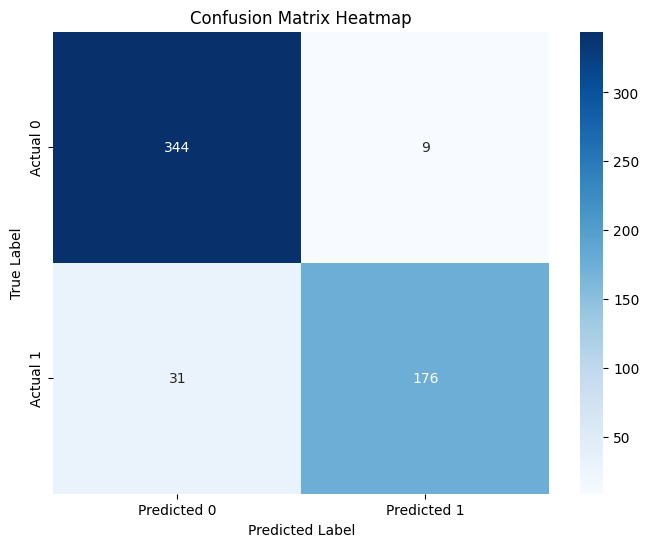

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()